# Domaine A - Notebook Rebuild (TTM Dataset 500)

Ce notebook refait le pipeline complet pour Mistral 7B Instruct + QLoRA a partir du dataset final de 500 exemples.

Pipeline:
1. Chargement et validation stricte du schema
2. Analyse quantitative (longueurs, richesse vocabulaire, repartitions)
3. Conversion vers formats Alpaca et Mistral
4. Split train/validation stratifie
5. Bloc d entrainement QLoRA pret a executer

In [ ]:
%pip install -q -U pandas numpy scikit-learn matplotlib seaborn datasets transformers peft trl accelerate bitsandbytes

In [1]:
from pathlib import Path
import json
import random
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_PATH = Path("ttm_corpus/ttm_dataset_instruction_500.json")
DOC_FAQ_PATH = Path("ttm_corpus/documents/01_FAQ_complete.json")
CATALOG_PATH = Path("ttm_corpus/catalog/products.json")
DOCS_DIR = Path("ttm_corpus/documents")

OUT_DIR = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_PATH.exists(), f"Missing dataset: {DATA_PATH}"
print(f"Dataset path: {DATA_PATH.resolve()}")

Dataset path: C:\Users\sotak\Documents\LLM\ttm_corpus\ttm_dataset_instruction_500.json


In [2]:
records = json.loads(DATA_PATH.read_text(encoding="utf-8"))
df = pd.DataFrame(records)

print(f"Rows loaded: {len(df)}")
display(df.head(3))

Rows loaded: 500


,id,category,instruction,conversation,response,sources,metadata
0,TTM-DS-0001,SAV,Je demande un rembursement apres retur valide....,[],Je ne dispose pas de cette information dans la...,"{'faq': ['FAQ-0216'], 'cgv': ['02_CGV_complete...","{'emotion': 'neutre', 'noise': True, 'negation..."
1,TTM-DS-0002,Produits,Quelle est la matiere de T-Shirt Essential 5 ?...,[],T-Shirt Essential 5 est propose en matieres: c...,"{'faq': ['FAQ-0062'], 'cgv': [], 'catalogue': ...","{'emotion': 'neutre', 'noise': False, 'negatio..."
2,TTM-DS-0003,SAV,Je demande un rembursement apres retur valide....,[],Nous ouvrons un dossier SAV. Envoyer etiquette...,"{'faq': ['FAQ-0191'], 'cgv': ['02_CGV_complete...","{'emotion': 'neutre', 'noise': False, 'negatio..."


In [3]:
# Validation stricte du schema et des contraintes de repartition
required_top = {"id", "category", "instruction", "conversation", "response", "sources", "metadata"}
required_sources = {"faq", "cgv", "catalogue", "policy"}
required_meta = {"emotion", "noise", "negation", "multiturn"}

errors = []
for i, row in enumerate(records, start=1):
    missing_top = required_top - set(row.keys())
    if missing_top:
        errors.append(f"Row {i}: missing top fields {sorted(missing_top)}")
        continue

    if not isinstance(row["conversation"], list):
        errors.append(f"Row {i}: conversation must be a list")

    src = row["sources"]
    if not isinstance(src, dict):
        errors.append(f"Row {i}: sources must be a dict")
    else:
        missing_src = required_sources - set(src.keys())
        if missing_src:
            errors.append(f"Row {i}: missing sources keys {sorted(missing_src)}")

    meta = row["metadata"]
    if not isinstance(meta, dict):
        errors.append(f"Row {i}: metadata must be a dict")
    else:
        missing_meta = required_meta - set(meta.keys())
        if missing_meta:
            errors.append(f"Row {i}: missing metadata keys {sorted(missing_meta)}")

assert not errors, "\n".join(errors[:20])

expected_counts = {
    "SAV": 195,
    "Produits": 150,
    "Compte": 70,
    "Livraison": 70,
    "Aberrations": 15,
}
actual_counts = df["category"].value_counts().to_dict()
assert actual_counts == expected_counts, f"Category mismatch: {actual_counts}"

noise_true = int(df["metadata"].apply(lambda m: bool(m.get("noise", False))).sum())
emotion_non_neutral = int(df["metadata"].apply(lambda m: m.get("emotion") != "neutre").sum())
negation_true = int(df["metadata"].apply(lambda m: bool(m.get("negation", False))).sum())
multiturn_true = int(df["metadata"].apply(lambda m: bool(m.get("multiturn", False))).sum())

assert noise_true >= 50, f"noise_true < 50: {noise_true}"
assert emotion_non_neutral >= 50, f"emotion_non_neutral < 50: {emotion_non_neutral}"
assert negation_true >= 50, f"negation_true < 50: {negation_true}"
assert multiturn_true >= 125, f"multiturn_true < 125: {multiturn_true}"

faq_ids = {x["id"] for x in json.loads(DOC_FAQ_PATH.read_text(encoding="utf-8"))["items"]}
sku_ids = {x["sku"] for x in json.loads(CATALOG_PATH.read_text(encoding="utf-8"))}
cgv_allowed = {"02_CGV_completes.md", "03_CGU_completes.md"}
policy_allowed = {p.name for p in DOCS_DIR.glob("*.md")} - cgv_allowed

for i, row in enumerate(records, start=1):
    src = row["sources"]
    for fid in src["faq"]:
        assert fid in faq_ids, f"Row {i}: invalid FAQ source {fid}"
    for did in src["cgv"]:
        assert did in cgv_allowed, f"Row {i}: invalid CGV source {did}"
    for sid in src["catalogue"]:
        assert sid in sku_ids, f"Row {i}: invalid catalogue source {sid}"
    for pid in src["policy"]:
        assert pid in policy_allowed, f"Row {i}: invalid policy source {pid}"

print("Validation complete: schema, quotas, and source references are consistent.")
print({
    "noise_true": noise_true,
    "emotion_non_neutral": emotion_non_neutral,
    "negation_true": negation_true,
    "multiturn_true": multiturn_true
})

Validation complete: schema, quotas, and source references are consistent.
{'noise_true': 92, 'emotion_non_neutral': 80, 'negation_true': 80, 'multiturn_true': 150}


In [ ]:
# Analyse quantitative avant conversion Alpaca/Mistral
def flatten_conversation(conv):
    if not conv:
        return ""
    parts = []
    for turn in conv:
        role = turn.get("role", "user")
        content = turn.get("content", "")
        parts.append(f"{role}: {content}")
    return " \n".join(parts)

def token_count(text):
    return len(re.findall(r"\w+", str(text).lower()))

df["conversation_text"] = df["conversation"].apply(flatten_conversation)
df["question_text"] = (df["instruction"].fillna("") + " " + df["conversation_text"].fillna("")).str.strip()
df["answer_text"] = df["response"].fillna("")

df["q_len"] = df["question_text"].apply(token_count)
df["a_len"] = df["answer_text"].apply(token_count)

def vocab_stats(series):
    tokens = []
    for txt in series:
        tokens.extend(re.findall(r"\w+", str(txt).lower()))
    unique = len(set(tokens))
    total = len(tokens)
    ttr = unique / total if total else 0.0
    return unique, total, ttr

q_unique, q_total, q_ttr = vocab_stats(df["question_text"])
a_unique, a_total, a_ttr = vocab_stats(df["answer_text"])

dup_instruction_ratio = float(df["instruction"].duplicated().mean())
dup_response_ratio = float(df["response"].duplicated().mean())

split_train, split_val = train_test_split(
    df[["category"]],
    test_size=0.2,
    random_state=SEED,
    stratify=df["category"]
)
split_table = pd.concat(
    [
        split_train["category"].value_counts().rename("train"),
        split_val["category"].value_counts().rename("validation")
    ],
    axis=1
).fillna(0).astype(int)
split_table["train_pct"] = (split_table["train"] / len(split_train) * 100).round(2)
split_table["validation_pct"] = (split_table["validation"] / len(split_val) * 100).round(2)

quant_summary = pd.DataFrame(
    [
        {"metric": "rows", "value": len(df)},
        {"metric": "avg_question_len_tokens", "value": round(df["q_len"].mean(), 2)},
        {"metric": "p95_question_len_tokens", "value": round(df["q_len"].quantile(0.95), 2)},
        {"metric": "avg_answer_len_tokens", "value": round(df["a_len"].mean(), 2)},
        {"metric": "p95_answer_len_tokens", "value": round(df["a_len"].quantile(0.95), 2)},
        {"metric": "dup_instruction_ratio", "value": round(dup_instruction_ratio, 4)},
        {"metric": "dup_response_ratio", "value": round(dup_response_ratio, 4)},
        {"metric": "q_vocab_unique", "value": q_unique},
        {"metric": "q_vocab_total", "value": q_total},
        {"metric": "q_ttr", "value": round(q_ttr, 4)},
        {"metric": "a_vocab_unique", "value": a_unique},
        {"metric": "a_vocab_total", "value": a_total},
        {"metric": "a_ttr", "value": round(a_ttr, 4)},
    ]
)

display(quant_summary)
display(split_table.sort_index())

,metric,value
0,rows,500.000
1,avg_question_len_tokens,0.000
2,p95_question_len_tokens,0.000
3,avg_answer_len_tokens,0.000
4,p95_answer_len_tokens,0.000
5,dup_instruction_ratio,0.236
6,dup_response_ratio,0.714
7,q_vocab_unique,0.000
8,q_vocab_total,0.000
9,q_ttr,0.000


,train,validation,train_pct,validation_pct
category,,,,
Aberrations,12,3,3.0,3.0
Compte,56,14,14.0,14.0
Livraison,56,14,14.0,14.0
Produits,120,30,30.0,30.0
SAV,156,39,39.0,39.0


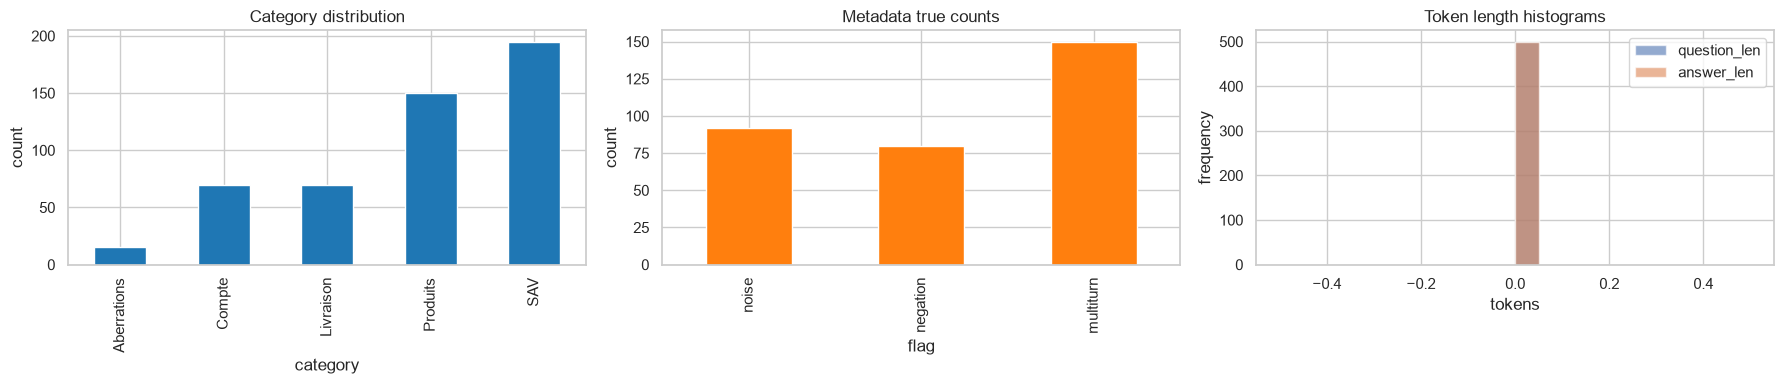

In [5]:
# Visualisations principales
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

df["category"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#1f77b4")
axes[0].set_title("Category distribution")
axes[0].set_xlabel("category")
axes[0].set_ylabel("count")

metadata_view = pd.DataFrame({
    "noise": df["metadata"].apply(lambda m: bool(m.get("noise", False))),
    "negation": df["metadata"].apply(lambda m: bool(m.get("negation", False))),
    "multiturn": df["metadata"].apply(lambda m: bool(m.get("multiturn", False)))
})
metadata_view.sum().plot(kind="bar", ax=axes[1], color="#ff7f0e")
axes[1].set_title("Metadata true counts")
axes[1].set_xlabel("flag")
axes[1].set_ylabel("count")

axes[2].hist(df["q_len"], bins=20, alpha=0.6, label="question_len")
axes[2].hist(df["a_len"], bins=20, alpha=0.6, label="answer_len")
axes[2].set_title("Token length histograms")
axes[2].set_xlabel("tokens")
axes[2].set_ylabel("frequency")
axes[2].legend()

plt.tight_layout()
plt.show()

In [6]:
# Conversion vers formats instruction tuning (Alpaca + Mistral [INST])
def render_history(conv):
    if not conv:
        return ""
    lines = []
    for turn in conv:
        role = turn.get("role", "user").upper()
        content = turn.get("content", "")
        lines.append(f"{role}: {content}")
    return "\n".join(lines)

def render_sources(src):
    chunks = []
    for key in ["faq", "cgv", "catalogue", "policy"]:
        vals = src.get(key, []) if isinstance(src, dict) else []
        if vals:
            chunks.append(f"{key}:{','.join(vals)}")
    return " | ".join(chunks) if chunks else "none"

def build_instruction(row):
    history = render_history(row["conversation"])
    question = str(row["instruction"]).strip()
    if history:
        return f"Contexte:\n{history}\n\nQuestion actuelle:\n{question}"
    return question

def build_output(row):
    answer = str(row["response"]).strip()
    src = render_sources(row["sources"])
    return f"{answer}\n\nSources: {src}"

formatted = pd.DataFrame({
    "id": df["id"],
    "category": df["category"],
    "instruction": df.apply(build_instruction, axis=1),
    "input": df["conversation"].apply(render_history),
    "output": df.apply(build_output, axis=1),
})

formatted["text"] = formatted.apply(
    lambda r: f"<s>[INST] {r['instruction']} [/INST] {r['output']}</s>",
    axis=1
)

display(formatted[["id", "category", "instruction", "input", "output", "text"]].head(2))

,id,category,instruction,input,output,text
0,TTM-DS-0001,SAV,Je demande un rembursement apres retur valide....,,Je ne dispose pas de cette information dans la...,<s>[INST] Je demande un rembursement apres ret...
1,TTM-DS-0002,Produits,Quelle est la matiere de T-Shirt Essential 5 ?...,,T-Shirt Essential 5 est propose en matieres: c...,<s>[INST] Quelle est la matiere de T-Shirt Ess...


In [ ]:
# Split train/validation stratifie et export des fichiers finaux
ALPACA_PATH = Path("ttm_corpus/ttm_dataset_instruction_500_alpaca.json")
MISTRAL_ALL_PATH = Path("ttm_corpus/ttm_dataset_instruction_500_mistral.jsonl")
TRAIN_PATH = Path("ttm_corpus/ttm_dataset_instruction_500_mistral_train.jsonl")
VAL_PATH = Path("ttm_corpus/ttm_dataset_instruction_500_mistral_val.jsonl")

train_df, val_df = train_test_split(
    formatted,
    test_size=0.2,
    random_state=SEED,
    stratify=formatted["category"]
)

split_actual = pd.concat(
    [
        train_df["category"].value_counts().rename("train"),
        val_df["category"].value_counts().rename("validation")
    ],
    axis=1
).fillna(0).astype(int).sort_index()

combined_df = pd.concat([train_df, val_df], ignore_index=True)
alpaca_records = combined_df[["id", "category", "instruction", "input", "output"]].to_dict("records")
ALPACA_PATH.write_text(json.dumps(alpaca_records, ensure_ascii=False, indent=2), encoding="utf-8")

def write_jsonl(path, records_list):
    with path.open("w", encoding="utf-8") as f:
        for rec in records_list:
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")

all_records = formatted[["id", "category", "instruction", "input", "output", "text"]].to_dict("records")
train_records = train_df[["id", "category", "instruction", "input", "output", "text"]].to_dict("records")
val_records = val_df[["id", "category", "instruction", "input", "output", "text"]].to_dict("records")

write_jsonl(MISTRAL_ALL_PATH, all_records)
write_jsonl(TRAIN_PATH, train_records)
write_jsonl(VAL_PATH, val_records)

print("Saved files:")
print(f"- {ALPACA_PATH}")
print(f"- {MISTRAL_ALL_PATH}")
print(f"- {TRAIN_PATH}")
print(f"- {VAL_PATH}")
display(split_actual)

In [ ]:
# Sanity check rapide des exemples finalises
sanity_cols = ["id", "category", "instruction", "input", "output"]
display(train_df[sanity_cols].sample(3, random_state=SEED))

multi_turn_view = train_df[train_df["input"].str.len() > 0][sanity_cols].head(2)
display(multi_turn_view)

## QLoRA Block (Optional)

Les cellules suivantes sont pretes pour un fine-tuning LoRA sur Mistral 7B Instruct v0.2.

Remarque: execution GPU recommandee.

In [ ]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, TrainingArguments
from peft import LoraConfig
from trl import SFTTrainer

BASE_MODEL = "mistralai/Mistral-7B-Instruct-v0.2"
TRAIN_FILE = str(TRAIN_PATH)
VAL_FILE = str(VAL_PATH)

train_dataset = load_dataset("json", data_files=TRAIN_FILE, split="train")
val_dataset = load_dataset("json", data_files=VAL_FILE, split="train")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,
)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    task_type="CAUSAL_LM",
)

print(train_dataset)
print(val_dataset)

In [ ]:
training_args = TrainingArguments(
    output_dir="outputs/ttm_mistral_qlora",
    num_train_epochs=1,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=10,
    evaluation_strategy="steps",
    eval_steps=50,
    save_steps=50,
    save_total_limit=2,
    report_to="none",
    seed=SEED,
)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    dataset_text_field="text",
    max_seq_length=1024,
    peft_config=lora_config,
    args=training_args,
    packing=False,
)

trainer

In [ ]:
# Lancer l entrainement quand l environnement GPU est pret
# trainer.train()
print("Trainer is ready. Uncomment trainer.train() to launch fine-tuning.")

In [ ]:
# Sauvegarde adapter et echantillons de validation
ADAPTER_DIR = Path("outputs/ttm_mistral_qlora_adapter")
# trainer.model.save_pretrained(ADAPTER_DIR)
# tokenizer.save_pretrained(ADAPTER_DIR)

eval_preview = val_df[["id", "category", "instruction", "output"]].head(5)
display(eval_preview)
print(f"Adapter output dir (planned): {ADAPTER_DIR}")